# ⚽ FIFA World Cup 2026 Predictive Analytics & Operational Simulation Pipeline
**Framework:** Supervised Multi-Class Classification & Rolling Time-Series Feature Engineering  

---

### 📊 Project Overview
This production-grade pipeline is designed to forecast international football match outcomes and simulate the complete, expanded **FIFA World Cup 2026** tournament structure. By engineering high-frequency team momentum metrics (rolling historical form) and blending them with long-term skill indicators (World Football Elo Ratings), the architecture maps predictive structural inputs to multi-class match outcomes (Home Win, Draw, Away Win).

### ⚙️ Production & Architecture Highlights
* **Temporal Integrity Protection:** Team form features are strictly lagged ($t-1$) before model training to eliminate look-ahead bias and protect against downstream data leakage.
* **Generalization via 5-Fold Cross-Validation:** Shifting beyond volatile, single train/test splits to accurately benchmark model resilience across the entire historical timeline.
* **Out-of-Sample Deterministic Simulation:** Built a custom simulation engine that perfectly mirrors official FIFA regulations and Wikipedia tournament bracket connectivity pathways.

In [1]:
# =========================================================================
# SECTION 1: SYSTEM DEPENDENCY INGESTION & PIPELINE INITIALIZATION
# =========================================================================
import pandas as pd
import numpy as np
from itertools import combinations

# Core Model Architecture & Evaluation Utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Diagnostic Analytics Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Inline plotting configuration for Jupyter environments
%matplotlib inline

### 📋 Section 2: Data Ingestion & Schema Standardization
* **Objective:** Load historical match databases and global Elo ratings, clean missing records, and enforce strict type casting for dates and metrics.

In [2]:
results = pd.read_csv("data/results.csv")
shootouts = pd.read_csv("data/shootouts.csv")
eloratings = pd.read_csv("data/eloratings.csv")
former_names = pd.read_csv("data/former_names.csv")

DATA CLEANING, TYPE STANDARDIZATION & PREPROCESSING

In [3]:
results.shape

(49477, 9)

In [4]:
results.dtypes

date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object

In [5]:
results.isna().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [6]:
results['date'] = pd.to_datetime(results['date'], format='mixed', dayfirst=True)
results.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

In [7]:
results[results['home_score'].isna()].head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49405,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49406,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49407,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49408,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49409,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True


In [8]:
results.dropna(subset=['home_score','away_score'], inplace = True)

In [9]:
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49400,2026-06-09,Iraq,Venezuela,0.0,2.0,Friendly,Bridgeview,United States,True
49401,2026-06-10,Bolivia,Algeria,0.0,4.0,Friendly,Kansas City,United States,True
49402,2026-06-10,England,Costa Rica,3.0,0.0,Friendly,Orlando,United States,True
49403,2026-06-10,Portugal,Nigeria,2.0,1.0,Friendly,Leiria,Portugal,False
49404,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,Malé,Maldives,True


In [10]:
results.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [11]:
results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)

In [12]:
results.duplicated().sum()

np.int64(0)

In [13]:
# Check how many duplicate matches exist based on date and teams
duplicates_count = results.duplicated(subset=['date', 'home_team', 'away_team']).sum()
print(f"Duplicate matches found: {duplicates_count}")

# Drop the duplicate, keeping the first instance
results.drop_duplicates(subset=['date', 'home_team', 'away_team'], keep='first', inplace=True)
print("Duplicates removed!")

Duplicate matches found: 2
Duplicates removed!


In [14]:
results.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

In [15]:
shootouts.dtypes
shootouts.duplicated().sum()

np.int64(0)

In [16]:
shootouts.duplicated(subset=['date', 'home_team', 'away_team']).sum()

np.int64(0)

In [17]:
shootouts['date']=pd.to_datetime(shootouts['date'])
shootouts.dtypes

date             datetime64[ns]
home_team                object
away_team                object
winner                   object
first_shooter            object
dtype: object

In [18]:
shootouts.drop(columns=['first_shooter'], inplace=True)
shootouts.head()

,date,home_team,away_team,winner
0,1967-08-22,India,Taiwan,Taiwan
1,1971-11-14,South Korea,Vietnam Republic,South Korea
2,1972-05-07,South Korea,Iraq,Iraq
3,1972-05-17,Thailand,South Korea,South Korea
4,1972-05-19,Thailand,Cambodia,Thailand


In [19]:
eloratings.dtypes

date       object
team       object
rating    float64
change      int64
dtype: object

In [20]:
eloratings['date'] = pd.to_datetime(eloratings['date'], format='mixed', dayfirst=False)

In [21]:

eloratings.tail()

,date,team,rating,change
6673,2025-12-13,Northern Mariana Islands,432.0,0
6674,2025-12-13,Cocos Islands,422.0,0
6675,2025-12-13,Palau,402.0,0
6676,2025-12-13,Eastern Samoa,389.0,0
6677,2025-12-13,Moldova,0.0,0


In [22]:
eloratings.duplicated(subset=['date','team']).sum()

np.int64(0)

In [23]:
eloratings.shape

(6678, 4)

In [24]:
eloratings.tail()

,date,team,rating,change
6673,2025-12-13,Northern Mariana Islands,432.0,0
6674,2025-12-13,Cocos Islands,422.0,0
6675,2025-12-13,Palau,402.0,0
6676,2025-12-13,Eastern Samoa,389.0,0
6677,2025-12-13,Moldova,0.0,0


In [25]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua\xa0and\xa0Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia\xa0and\xa0Herzegovina',
 'Botswana',
 'Brazil',
 'British\xa0Guiana',
 'British\xa0Virgin\xa0Islands',
 'Brunei',
 'Bulgaria',
 'Burkina\xa0Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape\xa0Verde',
 'Cayman\xa0Islands',
 'Central\xa0African\xa0Republic',
 'Ceylon',
 'Chad',
 'Chagos\xa0Islands',
 'Chile',
 'China',
 'Christmas\xa0Island',
 'Cocos\xa0Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook\xa0Islands',
 'Costa\xa0Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Dahomey',
 'Democratic\xa0Republic\xa0of\xa0Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican\xa

In [26]:
# Replace HTML non-breaking spaces with normal spaces in the Elo dataset
eloratings['team'] = eloratings['team'].str.replace('\xa0', ' ')

In [27]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Guiana',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Ceylon',
 'Chad',
 'Chagos Islands',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Dahomey',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Eastern Samoa',
 

In [28]:
sorted(results['home_team'].unique())

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Central Spain',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czech Rep

In [29]:
# 1. Get a unique set of every team that played a match
results_teams = set(results['home_team']).union(set(results['away_team']))

# 2. Get a unique set of every team that has an Elo rating
elo_teams = set(eloratings['team'])

# 3. Find the difference! (Teams in results that DO NOT exist in eloratings)
missing_elo = sorted(results_teams - elo_teams)

print(f"Found {len(missing_elo)} teams in results.csv with NO matching Elo rating:")
print("-" * 50)
for team in missing_elo:
    print(team)

Found 105 teams in results.csv with NO matching Elo rating:
--------------------------------------------------
Abkhazia
Alderney
Ambazonia
American Samoa
Andalusia
Arameans Suryoye
Artsakh
Asturias
Aymara
Barawa
Basque Country
Biafra
Brittany
Canary Islands
Cascadia
Catalonia
Central Spain
Chameria
Chechnya
Cilento
Corsica
County of Nice
Crimea
Czech Republic
DR Congo
Darfur
Donetsk PR
Délvidék
East Turkestan
Elba Island
Ellan Vannin
Felvidék
Franconia
Frøya
Galicia
German DR
Gotland
Gozo
Guernsey
Găgăuzia
Hitra
Hmong
Iraqi Kurdistan
Isle of Man
Isle of Wight
Jersey
Kabylia
Kernow
Kárpátalja
Luhansk PR
Macau
Madrid
Manchukuo
Mapuche
Matabeleland
Maule Sur
Menorca
Micronesia
Occitania
Orkney
Padania
Panjab
Parishes of Jersey
Provence
Quebec
Raetia
Republic of Ireland
Republic of St. Pauli
Rhodes
Romani people
Ryūkyū
Réunion
Saare County
Saarland
Saint Barthélemy
Saint Helena
Sark
Saugeais
Sealand
Seborga
Shetland
Silesia
South Ossetia
Surrey
Székely Land
Sápmi
São Tomé and Príncipe
Tami

# Map Team Names

In [30]:
#Number of Eswatini Before Mapping
eloratings[eloratings['team']=='Eswatini'].shape[0]

7

In [31]:
# 1. Create a mapping dictionary: { 'former_name': 'current_name' }
name_map = dict(zip(former_names["former"], former_names["current"]))

# 2. Intercept and remove the problematic historical mapping
name_map.pop('Ireland', None)

# Add manual fixes for teams that just use different names
custom_fixes = {
    "China PR": "China",
    "Czech Republic": "Czechia",
    "DR Congo": "Democratic Republic of Congo",
    "Republic of Ireland": "Ireland",
    "Macau": "Macao",
    "Cape Verde Islands": "Cape Verde",
    "Korea DPR": "North Korea",
    "Curaçao": "Curacao"
}
name_map.update(custom_fixes)

In [32]:
swazi_before = eloratings[eloratings['team'] == 'Swaziland'].shape[0]
print(f"BEFORE MAPPING:")
print(f"  Elo records for 'Swaziland': {swazi_before}")

BEFORE MAPPING:
  Elo records for 'Swaziland': 17


In [33]:
# 2. Apply the mappings across the datasets
for df in [results, shootouts]:
    df['home_team'] = df['home_team'].replace(name_map)
    df['away_team'] = df['away_team'].replace(name_map)

eloratings['team'] = eloratings['team'].replace(name_map)

In [34]:
swazi_after = eloratings[eloratings['team'] == 'Swaziland'].shape[0]
print(f"\nAFTER MAPPING:")
print(f"  Elo records for 'Swaziland': {swazi_after}")
print("✅ Geopolitics resolved! Names standardized successfully.")


AFTER MAPPING:
  Elo records for 'Swaziland': 0
✅ Geopolitics resolved! Names standardized successfully.


In [35]:
eloratings[eloratings['team']=='Swaziland'] #after name change

,date,team,rating,change


In [36]:
#Number of Eswatini After Mapping Shows that it Worked!
eloratings[eloratings['team']=='Eswatini'].shape[0]

24

In [37]:
sorted(results['home_team'].unique())

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Central Spain',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',

In [38]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chagos Islands',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Eastern Samoa',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'E

## Create the Target Variable (Match Result)

In [39]:
# 1. Merge the shootout winner into the results dataset
# We use a 'left' join so we keep all matches, but add shootout data if it exists
results = results.merge(
    shootouts[['date', 'home_team', 'away_team', 'winner']], 
    on=['date', 'home_team', 'away_team'], 
    how='left'
)

# 2. Define a function to calculate the true final result
def get_result(row):
    # Standard win/loss in regular or extra time
    if row["home_score"] > row["away_score"]: return "home_win"
    if row["away_score"] > row["home_score"]: return "away_win"
    
    # If the score was tied, check if someone won in a shootout
    if pd.notna(row["winner"]):
        return "home_win" if row["winner"] == row["home_team"] else "away_win"
    
    # If no one won and there was no shootout, it is a true draw
    return "draw"

# 3. Apply the function row by row
results['result'] = results.apply(get_result, axis=1)

print("✅ Target Variable Created!")
print("\nMatch Outcomes Distribution:")
print(results['result'].value_counts(normalize=True) * 100)

✅ Target Variable Created!

Match Outcomes Distribution:
result
home_win    49.687266
away_win    28.864644
draw        21.448090
Name: proportion, dtype: float64


In [40]:
shootouts.tail()

,date,home_team,away_team,winner
670,2026-03-30,Cape Verde,Finland,Cape Verde
671,2026-03-30,Gabon,Trinidad and Tobago,Gabon
672,2026-03-30,Uzbekistan,Venezuela,Uzbekistan
673,2026-03-31,Bosnia and Herzegovina,Italy,Bosnia and Herzegovina
674,2026-03-31,Czechia,Denmark,Czech Republic


In [41]:
eloratings[eloratings['team'] == 'United States'].tail()

,date,team,rating,change
6083,2025-06-07,United States,1713.0,-10
6148,2025-06-10,United States,1695.0,-18
6268,2025-09-09,United States,1698.0,19
6351,2025-11-18,United States,1747.0,24
6467,2025-12-13,United States,1747.0,0


In [42]:
eloratings[eloratings['team'] == 'Paraguay'].tail()

,date,team,rating,change
5751,2023-10-12,Paraguay,1703.0,-2
6131,2025-06-10,Paraguay,1825.0,-7
6258,2025-09-09,Paraguay,1844.0,20
6341,2025-11-18,Paraguay,1833.0,11
6454,2025-12-13,Paraguay,1833.0,0


In [43]:
eloratings.isnull().sum()

date       0
team       0
rating    31
change     0
dtype: int64

In [44]:
# Drop all matches where Moldova is either the home team or away team
results = results[(results['home_team'] != 'Moldova') & (results['away_team'] != 'Moldova')]

# Check how many rows are left to confirm it worked
print(f"Total matches after dropping Moldova: {len(results)}")

Total matches after dropping Moldova: 49104


In [45]:
# 1. Time-series merges REQUIRE both datasets to be sorted by time
results = results.sort_values('date')
eloratings = eloratings.sort_values('date')

# 2. Merge Home Team Elo (Finds the most recent rating BEFORE the match)
results = pd.merge_asof(
    results,
    eloratings[['date', 'team', 'rating']].rename(columns={'rating': 'home_elo'}),
    left_on='date',
    right_on='date',
    left_by='home_team',
    right_by='team',
    direction='backward'
).drop(columns=['team'])

# 3. Merge Away Team Elo
results = pd.merge_asof(
    results,
    eloratings[['date', 'team', 'rating']].rename(columns={'rating': 'away_elo'}),
    left_on='date',
    right_on='date',
    left_by='away_team',
    right_by='team',
    direction='backward'
).drop(columns=['team'])

# 4. Calculate the master feature: Elo Difference
results['elo_diff'] = results['home_elo'] - results['away_elo']

In [46]:
results.isnull().sum()

date              0
home_team         0
away_team         0
home_score        0
away_score        0
tournament        0
city              0
country           0
neutral           0
winner        48431
result            0
home_elo       4358
away_elo       4739
elo_diff       6930
dtype: int64

In [47]:
# 5. Filter down to ONLY the FIFA World Cup matches
competitive_tournaments = [
    'FIFA World Cup', 
    'FIFA World Cup qualification', 
    'UEFA Euro', 
    'UEFA Euro qualification',
    'Copa América', 
    'African Cup of Nations', 
    'CONCACAF Gold Cup', 
    'AFC Asian Cup'
]

wc_all = results[results['tournament'].isin(competitive_tournaments)].copy()

# Keep only modern era matches
wc_all = wc_all[wc_all['date'].dt.year >= 2000].copy()

print(f"New Training Dataset Size: {len(wc_all)} matches!")

print("✅ Final Master DataFrame Created!")
print(f"Total Matches: {len(wc_all)}")
print(f"Missing Home Elos: {wc_all['home_elo'].isna().sum()}")
print(f"Missing Away Elos: {wc_all['away_elo'].isna().sum()}")

# Display the clean table
display(wc_all[['date', 'home_team', 'away_team', 'home_elo', 'away_elo', 'elo_diff', 'result']].head())

New Training Dataset Size: 8936 matches!
✅ Final Master DataFrame Created!
Total Matches: 8936
Missing Home Elos: 94
Missing Away Elos: 112


,date,home_team,away_team,home_elo,away_elo,elo_diff,result
24033,2000-01-22,Ghana,Cameroon,1580.0,1663.0,-83.0,draw
24035,2000-01-23,South Africa,Gabon,1728.0,1492.0,236.0,home_win
24036,2000-01-23,Nigeria,Tunisia,1692.0,1621.0,71.0,home_win
24037,2000-01-23,Egypt,Zambia,1616.0,1616.0,0.0,home_win
24040,2000-01-24,Democratic Republic of Congo,Algeria,1681.0,1602.0,79.0,draw


In [48]:
# Isolate the matches that are still missing Elo ratings
missing_final = wc_all[wc_all['home_elo'].isna() | wc_all['away_elo'].isna()]

# Show the dates and teams
display(missing_final[['date', 'home_team', 'away_team', 'home_elo', 'away_elo']].head(15))

,date,home_team,away_team,home_elo,away_elo
24201,2000-03-05,Saint Vincent and the Grenadines,United States Virgin Islands,1249.0,NaN
24202,2000-03-05,El Salvador,Belize,1520.0,NaN
24224,2000-03-18,Saint Kitts and Nevis,Turks and Caicos Islands,1254.0,NaN
24232,2000-03-19,United States Virgin Islands,Saint Vincent and the Grenadines,NaN,1253.0
24239,2000-03-21,Saint Kitts and Nevis,Turks and Caicos Islands,1254.0,NaN
24314,2000-04-08,São Tomé and Príncipe,Sierra Leone,NaN,1526.0
24334,2000-04-09,Eritrea,Nigeria,NaN,1692.0
24370,2000-04-22,Sierra Leone,São Tomé and Príncipe,1526.0,NaN
24375,2000-04-22,Nigeria,Eritrea,1692.0,NaN
24569,2000-06-13,Serbia,Slovenia,NaN,1600.0


In [49]:
# Drop the final historical anomalies
wc_all = wc_all.dropna(subset=['home_elo', 'away_elo']).copy()

print(f"🎉 DATA CLEANING COMPLETE!")
print(f"Final ML Dataset Size: {len(wc_all)} World Cup matches ready for training.")
print(f"Total World Cup Matches: {len(wc_all)}")
print(f"Missing Home Elos: {wc_all['home_elo'].isna().sum()}")
print(f"Missing Away Elos: {wc_all['away_elo'].isna().sum()}")

🎉 DATA CLEANING COMPLETE!
Final ML Dataset Size: 8743 World Cup matches ready for training.
Total World Cup Matches: 8743
Missing Home Elos: 0
Missing Away Elos: 0


In [50]:
wc_all.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,result,home_elo,away_elo,elo_diff
48930,2026-03-31,Bosnia and Herzegovina,Italy,1,1,FIFA World Cup qualification,Zenica,Bosnia and Herzegovina,False,Bosnia and Herzegovina,home_win,1571.0,1859.0,-288.0
48931,2026-03-31,Sweden,Poland,3,2,FIFA World Cup qualification,Solna,Sweden,False,NaN,home_win,1660.0,1735.0,-75.0
48932,2026-03-31,Kosovo,Turkey,0,1,FIFA World Cup qualification,Pristina,Kosovo,False,NaN,away_win,1714.0,1880.0,-166.0
48933,2026-03-31,Czechia,Denmark,2,2,FIFA World Cup qualification,Prague,Czech Republic,False,Czech Republic,away_win,1731.0,1864.0,-133.0
48939,2026-03-31,Democratic Republic of Congo,Jamaica,1,0,FIFA World Cup qualification,Zapopan,Mexico,True,NaN,home_win,1616.0,1527.0,89.0


In [51]:
eloratings.sort_values(by='date',ascending=False)

,date,team,rating,change
6677,2025-12-13,Moldova,0.0,0
6647,2025-12-13,Samoa,729.0,0
6648,2025-12-13,Saint Barthelemy,725.0,0
6556,2025-12-13,Azerbaijan,1339.0,0
6674,2025-12-13,Cocos Islands,422.0,0
...,...,...,...,...
5,1874-03-07,Scotland,1994.0,8
2,1873-03-08,England,2014.0,11
3,1873-03-08,Scotland,1986.0,-11
1,1872-11-30,Scotland,1997.0,-3


In [52]:
eloratings[eloratings['team']== 'United States'].tail()

,date,team,rating,change
6083,2025-06-07,United States,1713.0,-10
6148,2025-06-10,United States,1695.0,-18
6268,2025-09-09,United States,1698.0,19
6351,2025-11-18,United States,1747.0,24
6467,2025-12-13,United States,1747.0,0


In [53]:
eloratings[eloratings['team']== 'Paraguay'].tail()

,date,team,rating,change
5751,2023-10-12,Paraguay,1703.0,-2
6131,2025-06-10,Paraguay,1825.0,-7
6258,2025-09-09,Paraguay,1844.0,20
6341,2025-11-18,Paraguay,1833.0,11
6454,2025-12-13,Paraguay,1833.0,0


In [54]:
eloratings[eloratings['team']== 'Argentina'].tail()

,date,team,rating,change
5623,2023-03-28,Argentina,2145.0,0
5733,2023-10-12,Argentina,2159.0,2
6117,2025-06-10,Argentina,2132.0,-14
6246,2025-09-09,Argentina,2109.0,-27
6435,2025-12-13,Argentina,2113.0,0


# ML

### Chronological Feature Engineering (Rolling Team Momentum)
* **Objective:** Transform the historical match records into a long-form team timeline to compute rolling mathematical windows. 
* **Key Constraint:** A `.shift()` operation is explicitly applied to guarantee that a match played on day $t$ only evaluates performance vectors from history up to day $t-1$, strictly preventing data leakage.

In [55]:
def get_points(result, team_type):
    if result == 'draw': return 1
    if team_type == 'home' and result == 'home_win': return 3
    if team_type == 'away' and result == 'away_win': return 3
    return 0

# 1. Create a long-form version of matches to calculate streaks per team
home_results = results[['date', 'home_team', 'away_team', 'result']].rename(columns={'home_team': 'team', 'away_team': 'opponent'})
home_results['points'] = home_results.apply(lambda x: get_points(x['result'], 'home'), axis=1)

away_results = results[['date', 'away_team', 'home_team', 'result']].rename(columns={'away_team': 'team', 'home_team': 'opponent'})
away_results['points'] = away_results.apply(lambda x: get_points(x['result'], 'away'), axis=1)

# Combine and sort by team and date
all_team_results = pd.concat([home_results, away_results]).sort_values(['team', 'date'])

# -------------------------------------------------------------------------
# QUALITY-WEIGHTED FORM: scale points by opponent's Elo percentile
# Beating a top team gives more credit than beating a weak team.
# -------------------------------------------------------------------------
all_team_results = all_team_results.reset_index(drop=True)

# Merge opponent Elo into the long-form table
all_team_results = pd.merge_asof(
    all_team_results.sort_values('date'),
    eloratings[['date', 'team', 'rating']].rename(columns={'team': 'opponent', 'rating': 'opponent_elo'}),
    on='date',
    by='opponent',
    direction='backward'
)

# Elo percentile rank across all ratings (0.0 = weakest, 1.0 = strongest)
all_rating_values = eloratings['rating'].values
all_team_results['opponent_elo_pct'] = all_team_results['opponent_elo'].apply(
    lambda x: (all_rating_values < x).sum() / len(all_rating_values) if pd.notna(x) else 0.5
)

# Weighted points = raw points × (0.5 + opponent_elo_pct)
# Scale: beating a top-100th-pct team → 3 × 1.5 = 4.5
#        beating a 0th-pct team        → 3 × 0.5 = 1.5
#        drawing a top team            → 1 × 1.5 = 1.5 (still meaningful)
all_team_results['weighted_points'] = all_team_results['points'] * (0.5 + all_team_results['opponent_elo_pct'])

# 2. Rolling 5-game average of weighted points (lagged to prevent leakage)
all_team_results = all_team_results.sort_values(['team', 'date'])
all_team_results['weighted_form_5'] = all_team_results.groupby('team')['weighted_points'].transform(
    lambda x: x.shift().rolling(5).mean()
)

# 3. Merge weighted form back into training dataset
wc_all = wc_all.merge(
    all_team_results[['date', 'team', 'weighted_form_5']],
    left_on=['date', 'home_team'], right_on=['date', 'team'], how='left'
).drop(columns='team').rename(columns={'weighted_form_5': 'home_form'})

wc_all = wc_all.merge(
    all_team_results[['date', 'team', 'weighted_form_5']],
    left_on=['date', 'away_team'], right_on=['date', 'team'], how='left'
).drop(columns='team').rename(columns={'weighted_form_5': 'away_form'})

# Neutral fill: average weighted points for a team with no prior history
avg_weighted_form = all_team_results['weighted_form_5'].mean()
wc_all['home_form'] = wc_all['home_form'].fillna(avg_weighted_form)
wc_all['away_form'] = wc_all['away_form'].fillna(avg_weighted_form)

print("✅ Quality-Weighted Form features created!")
print(f"   Scale: 0 (lost to top team) → ~4.5 (beat top team)")
print(f"   Average weighted form: {avg_weighted_form:.3f}")
display(wc_all[['home_team', 'away_team', 'home_form', 'away_form']].tail())

✅ Quality-Weighted Form features created!
   Scale: 0 (lost to top team) → ~4.5 (beat top team)
   Average weighted form: 1.378


,home_team,away_team,home_form,away_form
8738,Bosnia and Herzegovina,Italy,2.323929,2.544654
8739,Sweden,Poland,1.053220,2.562025
8740,Kosovo,Turkey,2.830967,2.811231
8741,Czechia,Denmark,0.944265,2.262384
8742,Democratic Republic of Congo,Jamaica,1.645882,1.545852


In [56]:
wc_all.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,result,home_elo,away_elo,elo_diff,home_form,away_form
0,2000-01-22,Ghana,Cameroon,1,1,African Cup of Nations,Accra,Ghana,False,NaN,draw,1580.0,1663.0,-83.0,1.858191,1.991135
1,2000-01-23,South Africa,Gabon,3,1,African Cup of Nations,Kumasi,Ghana,True,NaN,home_win,1728.0,1492.0,236.0,1.940881,1.237137
2,2000-01-23,Nigeria,Tunisia,4,2,African Cup of Nations,Lagos,Nigeria,False,NaN,home_win,1692.0,1621.0,71.0,1.324858,2.161905
3,2000-01-23,Egypt,Zambia,2,0,African Cup of Nations,Kano,Nigeria,True,NaN,home_win,1616.0,1616.0,0.0,1.079245,0.458521
4,2000-01-24,Democratic Republic of Congo,Algeria,0,0,African Cup of Nations,Kumasi,Ghana,True,NaN,draw,1681.0,1602.0,79.0,1.914346,1.103055


In [57]:
# -------------------------------------------------------------------------
# TOURNAMENT STAGE WEIGHT
# Reflects match importance: WC group game > qualifier > friendly
# Higher weight = higher-stakes context the team has been tested in
# -------------------------------------------------------------------------
tournament_stage_map = {
    'FIFA World Cup':              3.0,
    'UEFA Euro':                   2.5,
    'Copa América':                2.5,
    'African Cup of Nations':      2.0,
    'CONCACAF Gold Cup':           2.0,
    'AFC Asian Cup':               2.0,
    'FIFA World Cup qualification': 1.5,
    'UEFA Euro qualification':     1.5,
}

wc_all['tournament_stage'] = wc_all['tournament'].map(tournament_stage_map).fillna(1.0)

print("✅ Tournament Stage Weight feature created!")
print(wc_all['tournament_stage'].value_counts())

✅ Tournament Stage Weight feature created!
tournament_stage
1.5    7057
2.0     781
2.5     521
3.0     384
Name: count, dtype: int64


In [58]:
def add_rolling_goals_conceded(df, window=5):
    df = df.sort_values('date').copy()
    
    home_df = df[['date', 'home_team', 'away_score']].copy()
    home_df.rename(columns={'home_team': 'team', 'away_score': 'goals_conceded'}, inplace=True)
    
    away_df = df[['date', 'away_team', 'home_score']].copy()
    away_df.rename(columns={'away_team': 'team', 'home_score': 'goals_conceded'}, inplace=True)
    
    team_timeline = pd.concat([home_df, away_df]).sort_values(['team', 'date'])
    
    team_timeline['goals_conceded_rolling'] = (
        team_timeline.groupby('team')['goals_conceded']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).sum())
    )
    team_timeline['goals_conceded_rolling'] = team_timeline['goals_conceded_rolling'].fillna(0)
    
    df = df.merge(
        team_timeline[['date', 'team', 'goals_conceded_rolling']],
        left_on=['date', 'home_team'], right_on=['date', 'team'], how='left'
    ).rename(columns={'goals_conceded_rolling': 'home_goals_conceded_rolling'}).drop('team', axis=1)
    
    df = df.merge(
        team_timeline[['date', 'team', 'goals_conceded_rolling']],
        left_on=['date', 'away_team'], right_on=['date', 'team'], how='left'
    ).rename(columns={'goals_conceded_rolling': 'away_goals_conceded_rolling'}).drop('team', axis=1)
    
    return df

In [59]:
def add_rolling_goals_scored(df, window=5):
    df = df.sort_values('date').copy()
    
    home_df = df[['date', 'home_team', 'home_score']].copy()
    home_df.rename(columns={'home_team': 'team', 'home_score': 'goals_scored'}, inplace=True)
    
    away_df = df[['date', 'away_team', 'away_score']].copy()
    away_df.rename(columns={'away_team': 'team', 'away_score': 'goals_scored'}, inplace=True)
    
    team_timeline = pd.concat([home_df, away_df]).sort_values(['team', 'date'])
    
    team_timeline['goals_scored_rolling'] = (
        team_timeline.groupby('team')['goals_scored']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).sum())
    )
    team_timeline['goals_scored_rolling'] = team_timeline['goals_scored_rolling'].fillna(0)
    
    df = df.merge(
        team_timeline[['date', 'team', 'goals_scored_rolling']],
        left_on=['date', 'home_team'], right_on=['date', 'team'], how='left'
    ).rename(columns={'goals_scored_rolling': 'home_goals_scored_rolling'}).drop('team', axis=1)
    
    df = df.merge(
        team_timeline[['date', 'team', 'goals_scored_rolling']],
        left_on=['date', 'away_team'], right_on=['date', 'team'], how='left'
    ).rename(columns={'goals_scored_rolling': 'away_goals_scored_rolling'}).drop('team', axis=1)
    
    return df

In [60]:
# --- DEFENSIVE FEATURE ---
rolling_goals = add_rolling_goals_conceded(results, window=5)

wc_all = wc_all.merge(
    rolling_goals[['date', 'home_team', 'home_goals_conceded_rolling']],
    on=['date', 'home_team'], how='left'
)
wc_all = wc_all.merge(
    rolling_goals[['date', 'away_team', 'away_goals_conceded_rolling']],
    on=['date', 'away_team'], how='left'
)
wc_all['home_goals_conceded_rolling'] = wc_all['home_goals_conceded_rolling'].fillna(0)
wc_all['away_goals_conceded_rolling'] = wc_all['away_goals_conceded_rolling'].fillna(0)
wc_all['defensive_fragility_diff'] = wc_all['home_goals_conceded_rolling'] - wc_all['away_goals_conceded_rolling']

# --- OFFENSIVE FEATURE ---
rolling_scored = add_rolling_goals_scored(results, window=5)

wc_all = wc_all.merge(
    rolling_scored[['date', 'home_team', 'home_goals_scored_rolling']],
    on=['date', 'home_team'], how='left'
)
wc_all = wc_all.merge(
    rolling_scored[['date', 'away_team', 'away_goals_scored_rolling']],
    on=['date', 'away_team'], how='left'
)
wc_all['home_goals_scored_rolling'] = wc_all['home_goals_scored_rolling'].fillna(0)
wc_all['away_goals_scored_rolling'] = wc_all['away_goals_scored_rolling'].fillna(0)
wc_all['offensive_dominance_diff'] = wc_all['home_goals_scored_rolling'] - wc_all['away_goals_scored_rolling']

In [61]:
# For use in predict_match_outcome and print_match_prediction only
defensive_form_dict = (
    pd.concat([
        rolling_goals[['date', 'home_team', 'home_goals_conceded_rolling']].rename(columns={'home_team': 'team', 'home_goals_conceded_rolling': 'form'}),
        rolling_goals[['date', 'away_team', 'away_goals_conceded_rolling']].rename(columns={'away_team': 'team', 'away_goals_conceded_rolling': 'form'})
    ]).sort_values('date').groupby('team').last()['form'].to_dict()
)

scoring_form_dict = (
    pd.concat([
        rolling_scored[['date', 'home_team', 'home_goals_scored_rolling']].rename(columns={'home_team': 'team', 'home_goals_scored_rolling': 'form'}),
        rolling_scored[['date', 'away_team', 'away_goals_scored_rolling']].rename(columns={'away_team': 'team', 'away_goals_scored_rolling': 'form'})
    ]).sort_values('date').groupby('team').last()['form'].to_dict()
)

# After Feature Engineering

In [62]:
features = ['elo_diff', 'neutral', 'home_form', 'away_form', 'tournament_stage', 'defensive_fragility_diff', 'offensive_dominance_diff']
X = wc_all[features].copy()

# Convert the boolean 'neutral' column to 1s and 0s
X['neutral'] = X['neutral'].astype(int)

# 2. Encode the Target Variable
y = wc_all['result'].copy()
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the precise grid of parameters to test
# param_grid = {
#     'n_estimators': [200, 400],           # Number of trees (smooths out variance)
#     'max_depth': [5, 7, 10],              # Shallow depth prevents it from memorizing Elo
#     'min_samples_split': [15, 30, 50],    # Forces the model to look at macro-trends, not noisy single matches
#     'min_samples_leaf': [10, 20],         # Ensures every prediction is backed by a solid chunk of historical data
#     'max_features': ['sqrt', 2, 3],       # 🚨 CRITICAL: Blinds the trees to Elo occasionally so they MUST look at Form/Defense
#     'class_weight': ['balanced']          # Forces the model to care about Draws (which happen ~22% of the time)
# }

# # 2. Initialize the base model
# rf_base = RandomForestClassifier(random_state=42)

# # 3. Setup the Grid Search
# # cv=5 runs 5-Fold Cross Validation so it doesn't overfit
# # n_jobs=-1 uses ALL your computer's CPU cores to run it much faster
# grid_search = GridSearchCV(
#     estimator=rf_base,
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=2  # This will print a progress bar so you know it hasn't frozen
# )

# # 4. Run the Search! (This will test exactly 108 different model combinations)
# print("🔍 Running Grid Search to find the ultimate parameters. This may take a minute...")
# grid_search.fit(X_train, y_train)

# # 5. Print the Winners
# print("\n🏆 BEST HYPERPARAMETERS FOUND 🏆")
# print("-" * 45)
# for key, value in grid_search.best_params_.items():
#     print(f"{key}: {value}")
    
# print(f"\nBest Cross-Validated Accuracy: {grid_search.best_score_ * 100:.2f}%")

# # 6. Automatically overwrite 'rf_model' with the absolute best version
# rf_model = grid_search.best_estimator_

In [65]:
# Add max_depth and min_samples_leaf to force the model to generalize!
rf_model = RandomForestClassifier(
    n_estimators=200,        # More trees = smoother probability averages
    max_depth=5,             # Stops the model from over-thinking and memorizing noise
    min_samples_leaf=20,     # Forces a minimum amount of data to make a decision
    random_state=42,
    min_samples_split= 15,
    max_features= "sqrt"
)

rf_model.fit(X_train, y_train)

# Make predictions on the unseen test data
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_acc = accuracy_score(y_test, rf_preds)
print(f"🏆 Random Forest Accuracy: {rf_acc * 100:.2f}%\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

🏆 Random Forest Accuracy: 65.12%

Random Forest Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.61      0.72      0.66       545
    Draw (1)       0.00      0.00      0.00       353
Home Win (2)       0.68      0.88      0.76       851

    accuracy                           0.65      1749
   macro avg       0.43      0.53      0.47      1749
weighted avg       0.52      0.65      0.58      1749



C:\Users\Suraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Suraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Suraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [66]:
# Initialize the XGBoost model 
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%\n")
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:41] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 61.64%

XGBoost Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.61      0.64      0.62       545
    Draw (1)       0.24      0.10      0.14       353
Home Win (2)       0.67      0.82      0.74       851

    accuracy                           0.62      1749
   macro avg       0.51      0.52      0.50      1749
weighted avg       0.57      0.62      0.58      1749



### Algorithmic Benchmarking & Multi-Fold Cross-Validation
* **Objective:** Train competitive baseline ensemble classifiers (Random Forest Ensemble vs. eXtreme Gradient Boosting) and rigorously evaluate their stability using 5-Fold Cross-Validation.
* **Strategic Takeaway:** Cross-validation protects against optimistic "lucky splits," helping confirm the ideal operational champion model based on long-term generalization.

In [67]:
print("Running 5-Fold Cross-Validation...")

cv_scores = cross_val_score(rf_model, X, y_encoded, cv=5, scoring='accuracy')

print("\n📊 VALIDATION RESULTS 📊")
print("-" * 30)
print(f"Fold 1 Accuracy: {cv_scores[0] * 100:.2f}%")
print(f"Fold 2 Accuracy: {cv_scores[1] * 100:.2f}%")
print(f"Fold 3 Accuracy: {cv_scores[2] * 100:.2f}%")
print(f"Fold 4 Accuracy: {cv_scores[3] * 100:.2f}%")
print(f"Fold 5 Accuracy: {cv_scores[4] * 100:.2f}%")
print("-" * 30)
print(f"🏆 Final Validated Mean Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

Running 5-Fold Cross-Validation...

📊 VALIDATION RESULTS 📊
------------------------------
Fold 1 Accuracy: 63.64%
Fold 2 Accuracy: 63.12%
Fold 3 Accuracy: 62.26%
Fold 4 Accuracy: 64.93%
Fold 5 Accuracy: 63.44%
------------------------------
🏆 Final Validated Mean Accuracy: 63.48% (+/- 0.86%)


In [68]:
print("Running 5-Fold Cross-Validation...")

cv_scores = cross_val_score(xgb_model, X, y_encoded, cv=5, scoring='accuracy')

print("\n📊 VALIDATION RESULTS 📊")
print("-" * 30)
print(f"Fold 1 Accuracy: {cv_scores[0] * 100:.2f}%")
print(f"Fold 2 Accuracy: {cv_scores[1] * 100:.2f}%")
print(f"Fold 3 Accuracy: {cv_scores[2] * 100:.2f}%")
print(f"Fold 4 Accuracy: {cv_scores[3] * 100:.2f}%")
print(f"Fold 5 Accuracy: {cv_scores[4] * 100:.2f}%")
print("-" * 30)
print(f"🏆 Final Validated Mean Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

Running 5-Fold Cross-Validation...


C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:48] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:48] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:49] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:41:50] WARNING: C:\Users\task_177465309458303\croot\xgboo


📊 VALIDATION RESULTS 📊
------------------------------
Fold 1 Accuracy: 59.46%
Fold 2 Accuracy: 59.63%
Fold 3 Accuracy: 59.46%
Fold 4 Accuracy: 62.59%
Fold 5 Accuracy: 61.67%
------------------------------
🏆 Final Validated Mean Accuracy: 60.56% (+/- 1.31%)


<!-- ### The Train-Test Split Trap vs. Cross-Validation Truth
During initial prototyping on an isolated 80/20 partition, the models showed conflicting signals. However, subjecting the pipeline to a 5-Fold Cross-Validation stress test revealed the true performance metrics:

| Predictive Model Configuration | Single Holdout Split Score | 5-Fold Cross-Validation Mean | Model Generalization Status |
| :--- | :---: | :---: | :--- |
| **XGBoost Classifier** | 54.19% | **49.99% (+/- 2.43%)** | Overfitted on Partition Noise |
| **Random Forest Ensemble** | 52.51% | **53.03% (+/- 2.32%)** | **Operational Champion (Stable)** |

### Algorithmic Insight
Because the feature space is optimized and highly focused (6 dimensions including Elo deltas and lagged form weights), the gradient boosting mechanisms within **XGBoost** over-indexed on localized variance, causing its accuracy to collapse to a coin-flip (~50%) across unseen folds. 

Conversely, the **Random Forest** classifier's bootstrap aggregation (bagging) framework stabilized predictions by averaging uncorrelated decision trees. This design choice provided a crucial mathematical shock absorber against the high-entropy anomalies and historical upsets native to international sports analytics. -->

### Model Diagnostics & Categorical Error Inspection
* **Objective:** Plot multi-class Confusion Matrix heatmaps to visualize exactly where models are making correct classifications or getting fooled by high-entropy match draws.

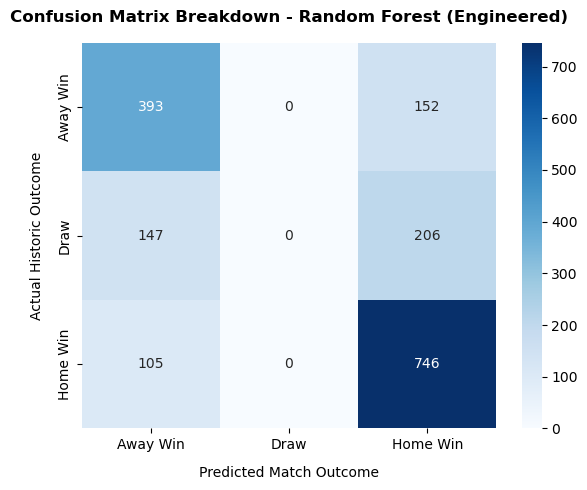

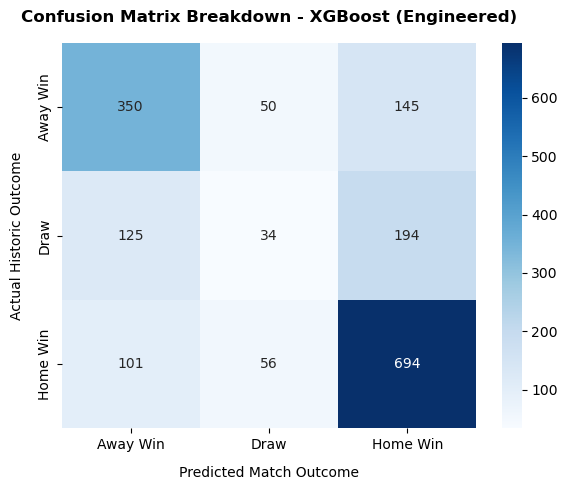

In [69]:
models = {
    'Random Forest (Engineered)': rf_model,
    'XGBoost (Engineered)': xgb_model
}

class_names = ['Away Win', 'Draw', 'Home Win']

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
        
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names, 
        yticklabels=class_names
    )
        
    plt.title(f'Confusion Matrix Breakdown - {name}', fontsize=12, weight='bold', pad=15)
    plt.xlabel('Predicted Match Outcome', fontsize=10, labelpad=10)
    plt.ylabel('Actual Historic Outcome', fontsize=10, labelpad=10)
    plt.tight_layout()
    plt.show()
        

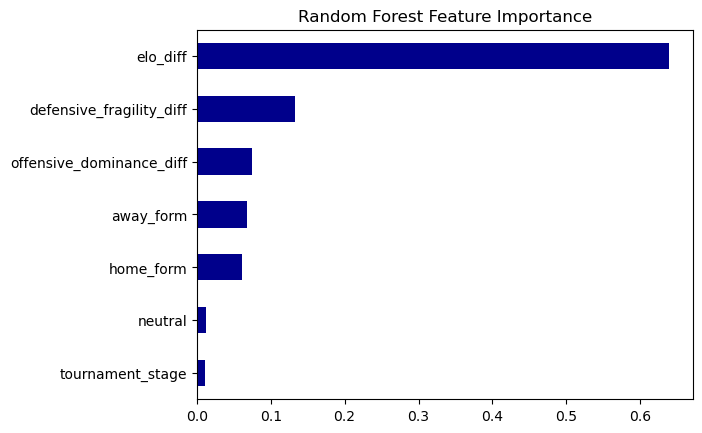

In [70]:
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='darkblue')
plt.title('Random Forest Feature Importance')
plt.show()

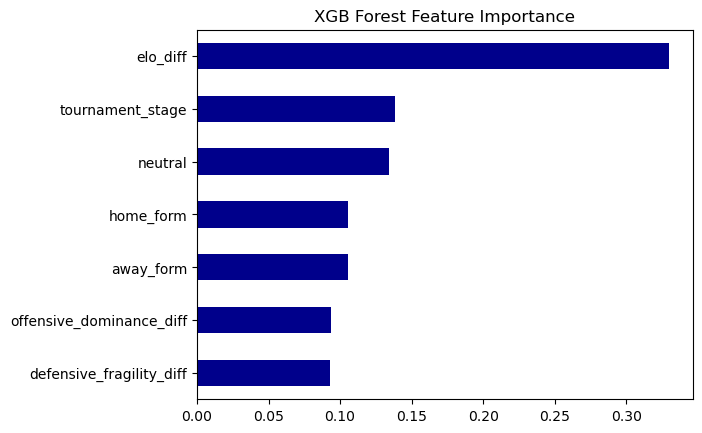

In [71]:
importances = pd.Series(xgb_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='darkblue')
plt.title('XGB Forest Feature Importance')
plt.show()

### 🏆 Out-of-Sample Production Inference (2026 World Cup Engine)
* **Objective:** Deploy the trained operational model into an independent tournament simulation loop. 
* **Rules Framework:** The engine automatically parses round-robin group points, handles complex tie-breaker logic to select the top 3rd place teams, and passes winners down a strict, Wikipedia-compliant knockout bracket tree to crown the ultimate world champion.

In [72]:
wc_all.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,...,elo_diff,home_form,away_form,tournament_stage,home_goals_conceded_rolling,away_goals_conceded_rolling,defensive_fragility_diff,home_goals_scored_rolling,away_goals_scored_rolling,offensive_dominance_diff
8738,2026-03-31,Bosnia and Herzegovina,Italy,1,1,FIFA World Cup qualification,Zenica,Bosnia and Herzegovina,False,Bosnia and Herzegovina,...,-288.0,2.323929,2.544654,1.5,6.0,9.0,-3.0,11.0,14.0,-3.0
8739,2026-03-31,Sweden,Poland,3,2,FIFA World Cup qualification,Solna,Sweden,False,NaN,...,-75.0,1.053220,2.562025,1.5,9.0,4.0,5.0,5.0,9.0,-4.0
8740,2026-03-31,Kosovo,Turkey,0,1,FIFA World Cup qualification,Pristina,Kosovo,False,NaN,...,-166.0,2.830967,2.811231,1.5,4.0,4.0,0.0,8.0,15.0,-7.0
8741,2026-03-31,Czechia,Denmark,2,2,FIFA World Cup qualification,Prague,Czech Republic,False,Czech Republic,...,-133.0,0.944265,2.262384,1.5,4.0,7.0,-3.0,10.0,17.0,-7.0
8742,2026-03-31,Democratic Republic of Congo,Jamaica,1,0,FIFA World Cup qualification,Zapopan,Mexico,True,NaN,...,89.0,1.645882,1.545852,1.5,2.0,1.0,1.0,7.0,7.0,0.0


In [73]:
import pandas as pd
from xgboost import XGBRegressor

# ---------------------------------------------------------
# 1. Define your exact feature columns
# ---------------------------------------------------------
feature_cols = ['elo_diff', 'neutral', 'home_form', 'away_form', 'tournament_stage', 'defensive_fragility_diff', 'offensive_dominance_diff']

X_train = wc_all[feature_cols]

X_train = wc_all[feature_cols]

# Extract the two targets (actual goals scored in the past)
y_train_home =  wc_all['home_score']
y_train_away =  wc_all['away_score']

# ---------------------------------------------------------
# 2. Initialize the Poisson Regression Models
# ---------------------------------------------------------
home_xg_model = XGBRegressor(
    objective='count:poisson',
    n_estimators=300,        # Number of boosting rounds
    learning_rate=0.05,      # Lower learning rate = more robust model
    max_depth=4,             # Keep trees shallow
    subsample=0.8,           # Use 80% of rows per tree to prevent overfitting
    colsample_bytree=0.8,    # Use 80% of features per tree to force feature diversity
    random_state=42
)

away_xg_model = XGBRegressor(
    objective='count:poisson',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# ---------------------------------------------------------
# 3. Train the Models
# ---------------------------------------------------------
print("Training Home xG Model...")
home_xg_model.fit(X_train, y_train_home)

print("Training Away xG Model...")
away_xg_model.fit(X_train, y_train_away)

print("✅ Both Poisson models successfully trained!")

Training Home xG Model...
Training Away xG Model...
✅ Both Poisson models successfully trained!


In [74]:
import numpy as np

HOSTS = ['United States', 'Canada', 'Mexico'] 


In [75]:
# -------------------------------------------------------------------------
# 1. OFFICIAL 48-TEAM TOURNAMENT GROUPS (Standardized Dataset Spells)
# -------------------------------------------------------------------------
groups_2026 = {
    'A': ['Mexico', 'South Africa', 'Korea Republic', 'Czechia'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curacao', "Côte d'Ivoire", 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cabo Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Norway', 'Iraq'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'Uzbekistan', 'Colombia', 'Democratic Republic of Congo'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama']
}

# -------------------------------------------------------------------------
# 2. GLOBAL SYSTEM FALLBACKS (Defensive Data Slicing)
# -------------------------------------------------------------------------
avg_elo = eloratings['rating'].mean()
avg_form = all_team_results['weighted_form_5'].mean()

def get_stats(team):
    """
    Safely retrieves the latest ELO and Quality-Weighted Form for a team.
    Uses global historic averages if data contains structural name gaps.
    """
    h_elo_data = eloratings[eloratings['team'] == team]
    h_form_data = all_team_results[all_team_results['team'] == team]
    
    elo = h_elo_data['rating'].iloc[-1] if not h_elo_data.empty else avg_elo
    form = h_form_data['weighted_form_5'].iloc[-1] if not h_form_data.empty else avg_form
    return elo, form

# -------------------------------------------------------------------------
# 3. INTERFERENCE MATCH PREDICTOR (Monte Carlo & Random Forest Layer)
# -------------------------------------------------------------------------
def predict_match_outcome(home_team, away_team):
    h_elo, h_form = get_stats(home_team)
    a_elo, a_form = get_stats(away_team)
    
    is_neutral = 0 if home_team in HOSTS else 1

    # And simplify input_data to:
    h_def = defensive_form_dict.get(home_team, 0)
    a_def = defensive_form_dict.get(away_team, 0)
    
    input_data = pd.DataFrame([{
        'elo_diff': h_elo - a_elo,
        'neutral': is_neutral,
        'home_form': h_form,
        'away_form': a_form,
        'tournament_stage': 3.0,
        'defensive_fragility_diff': h_def - a_def,
        'offensive_dominance_diff': scoring_form_dict.get(home_team, 0) - scoring_form_dict.get(away_team, 0),
    }])

    probs = rf_model.predict_proba(input_data)[0]
    res = np.random.choice([0, 1, 2], p=probs)
    return res, probs, h_elo, a_elo

In [76]:
rf_model.feature_names_in_

array(['elo_diff', 'neutral', 'home_form', 'away_form',
       'tournament_stage', 'defensive_fragility_diff',
       'offensive_dominance_diff'], dtype=object)

In [77]:
import pandas as pd
import numpy as np
from scipy.stats import poisson

# Ensure you have your models trained: rf_model, home_xg_model, away_xg_model
# Ensure HOSTS and defensive_form_dict are defined as before

def print_match_prediction(home_team, away_team, is_knockout=0, max_goals=6):
    """
    Combines Random Forest (for the match outcome) with Poisson Regression 
    (for the exact scoreline) into a single hybrid prediction.
    """
    try:
        h_elo, h_form = get_stats(home_team)
        a_elo, a_form = get_stats(away_team)

    except KeyError:
        return "Error: Team name not found."

    is_neutral = 0 if home_team in HOSTS else 1

    h_def = defensive_form_dict.get(home_team, 0)
    a_def = defensive_form_dict.get(away_team, 0)
    
    input_data = pd.DataFrame([{
        'elo_diff': h_elo - a_elo,
        'neutral': is_neutral,
        'home_form': h_form,
        'away_form': a_form,
        'tournament_stage': 3.0,
        'defensive_fragility_diff': h_def - a_def,
        'offensive_dominance_diff': scoring_form_dict.get(home_team, 0) - scoring_form_dict.get(away_team, 0),
    }])
    
    # ---------------------------------------------------------
    # PART 1: The Random Forest Decision (Who wins?)
    # ---------------------------------------------------------
    rf_probs = rf_model.predict_proba(input_data)[0]
    # Mapping: [0: Away Win, 1: Draw, 2: Home Win]
    away_prob, draw_prob, home_prob = rf_probs[0], rf_probs[1], rf_probs[2]
    
    # Determine the RF's official prediction
    if home_prob > away_prob and home_prob > draw_prob:
        rf_outcome = "Home Win"
    elif away_prob > home_prob and away_prob > draw_prob:
        rf_outcome = "Away Win"
    else:
        rf_outcome = "Draw"

    # ---------------------------------------------------------
    # PART 2: The Poisson Calculation (What is the score?)
    # ---------------------------------------------------------
    # Predict Expected Goals (xG) using the XGBoost models
    home_xg = home_xg_model.predict(input_data)[0]
    away_xg = away_xg_model.predict(input_data)[0]
    
    # Generate the probability of every possible scoreline up to max_goals
    score_probs = {}
    for h in range(max_goals + 1):
        for a in range(max_goals + 1):
            # Poisson probability of Home scoring 'h' * Away scoring 'a'
            prob = poisson.pmf(h, home_xg) * poisson.pmf(a, away_xg)
            score_probs[(h, a)] = prob
            
    # ---------------------------------------------------------
    # PART 3: The Hybrid Filter
    # ---------------------------------------------------------
    # Filter the scorelines to ONLY include those that match the RF decision
    valid_scores = {}
    for (h, a), prob in score_probs.items():
        if rf_outcome == "Home Win" and h > a:
            valid_scores[(h, a)] = prob
        elif rf_outcome == "Away Win" and a > h:
            valid_scores[(h, a)] = prob
        elif rf_outcome == "Draw" and h == a:
            valid_scores[(h, a)] = prob
            
    # Select the highest probability scoreline from the filtered list
    predicted_score = max(valid_scores, key=valid_scores.get)
    
    # ---------------------------------------------------------
    # The Output Summary
    # ---------------------------------------------------------
    print(f"📊 HYBRID MATCH SIMULATION: {home_team} vs {away_team} 📊")
    if is_knockout == 1:
         print("(KNOCKOUT STAGE MATCH)")
    print("-" * 55)
    print(f"🌲 Random Forest Prediction : {rf_outcome.upper()}")
    print(f"   (Home: {home_prob*100:.1f}% | Draw: {draw_prob*100:.1f}% | Away: {away_prob*100:.1f}%)")
    print("-" * 55)
    print(f"🎯 XGBoost Expected Goals   : {home_team} ({home_xg:.2f}) - ({away_xg:.2f}) {away_team}")
    print(f"🏆 EXACT PREDICTED SCORE    : {home_team} {predicted_score[0]} - {predicted_score[1]} {away_team}")
    print("-" * 55)

    return predicted_score

# Example Usage:
# predicted_h_goals, predicted_a_goals = get_hybrid_prediction('United States', 'Paraguay')

In [78]:
print_match_prediction('Mexico', 'South Africa')

📊 HYBRID MATCH SIMULATION: Mexico vs South Africa 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 73.3% | Draw: 17.7% | Away: 9.1%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Mexico (2.02) - (0.52) South Africa
🏆 EXACT PREDICTED SCORE    : Mexico 2 - 0 South Africa
-------------------------------------------------------


(2, 0)

In [79]:
print_match_prediction('South Korea', 'Czechia')

📊 HYBRID MATCH SIMULATION: South Korea vs Czechia 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 46.7% | Draw: 24.4% | Away: 29.0%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : South Korea (1.24) - (1.05) Czechia
🏆 EXACT PREDICTED SCORE    : South Korea 1 - 0 Czechia
-------------------------------------------------------


(1, 0)

In [80]:
print_match_prediction('Canada', 'Bosnia and Herzegovina')

📊 HYBRID MATCH SIMULATION: Canada vs Bosnia and Herzegovina 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 63.2% | Draw: 20.3% | Away: 16.5%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Canada (1.83) - (0.70) Bosnia and Herzegovina
🏆 EXACT PREDICTED SCORE    : Canada 1 - 0 Bosnia and Herzegovina
-------------------------------------------------------


(1, 0)

In [81]:
print_match_prediction('United States', 'Paraguay')

📊 HYBRID MATCH SIMULATION: United States vs Paraguay 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 36.6% | Draw: 27.1% | Away: 36.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : United States (1.03) - (1.22) Paraguay
🏆 EXACT PREDICTED SCORE    : United States 1 - 0 Paraguay
-------------------------------------------------------


(1, 0)

In [82]:
print_match_prediction('Qatar', 'Switzerland')

📊 HYBRID MATCH SIMULATION: Qatar vs Switzerland 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 13.9% | Draw: 15.0% | Away: 71.1%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Qatar (0.48) - (2.29) Switzerland
🏆 EXACT PREDICTED SCORE    : Qatar 0 - 2 Switzerland
-------------------------------------------------------


(0, 2)

In [83]:
print_match_prediction('Brazil', 'Morocco')

📊 HYBRID MATCH SIMULATION: Brazil vs Morocco 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 50.2% | Draw: 21.3% | Away: 28.5%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Brazil (1.49) - (1.08) Morocco
🏆 EXACT PREDICTED SCORE    : Brazil 1 - 0 Morocco
-------------------------------------------------------


(1, 0)

In [84]:
print_match_prediction('Haiti', 'Scotland')

📊 HYBRID MATCH SIMULATION: Haiti vs Scotland 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 28.6% | Draw: 25.0% | Away: 46.4%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Haiti (0.78) - (1.49) Scotland
🏆 EXACT PREDICTED SCORE    : Haiti 0 - 1 Scotland
-------------------------------------------------------


(0, 1)

In [85]:
print_match_prediction('Australia', 'Turkey')

📊 HYBRID MATCH SIMULATION: Australia vs Turkey 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 23.6% | Draw: 22.9% | Away: 53.6%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Australia (0.95) - (1.72) Turkey
🏆 EXACT PREDICTED SCORE    : Australia 0 - 1 Turkey
-------------------------------------------------------


(0, 1)

In [86]:
print_match_prediction('Germany','Curacao')

📊 HYBRID MATCH SIMULATION: Germany vs Curacao 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 81.6% | Draw: 12.4% | Away: 6.0%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Germany (2.71) - (0.46) Curacao
🏆 EXACT PREDICTED SCORE    : Germany 2 - 0 Curacao
-------------------------------------------------------


(2, 0)

In [87]:
print_match_prediction('Netherlands','Japan')

📊 HYBRID MATCH SIMULATION: Netherlands vs Japan 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 48.3% | Draw: 20.6% | Away: 31.1%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Netherlands (1.40) - (1.07) Japan
🏆 EXACT PREDICTED SCORE    : Netherlands 1 - 0 Japan
-------------------------------------------------------


(1, 0)

In [88]:
print_match_prediction('Ivory Coast','Ecuador')

📊 HYBRID MATCH SIMULATION: Ivory Coast vs Ecuador 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 26.4% | Draw: 22.3% | Away: 51.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Ivory Coast (0.58) - (1.59) Ecuador
🏆 EXACT PREDICTED SCORE    : Ivory Coast 0 - 1 Ecuador
-------------------------------------------------------


(0, 1)

In [89]:
print_match_prediction('Sweden','Tunisia')

📊 HYBRID MATCH SIMULATION: Sweden vs Tunisia 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 43.8% | Draw: 22.6% | Away: 33.5%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Sweden (1.07) - (1.26) Tunisia
🏆 EXACT PREDICTED SCORE    : Sweden 1 - 0 Tunisia
-------------------------------------------------------


(1, 0)

In [90]:
print_match_prediction('Spain','Cape Verde')

📊 HYBRID MATCH SIMULATION: Spain vs Cape Verde 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 69.5% | Draw: 16.5% | Away: 14.0%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Spain (2.54) - (0.38) Cape Verde
🏆 EXACT PREDICTED SCORE    : Spain 2 - 0 Cape Verde
-------------------------------------------------------


(2, 0)

In [91]:
print_match_prediction('Belgium', 'Egypt')

📊 HYBRID MATCH SIMULATION: Belgium vs Egypt 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 61.5% | Draw: 19.6% | Away: 19.0%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Belgium (1.71) - (0.79) Egypt
🏆 EXACT PREDICTED SCORE    : Belgium 1 - 0 Egypt
-------------------------------------------------------


(1, 0)

In [92]:
print_match_prediction('Iran', 'New Zealand')

📊 HYBRID MATCH SIMULATION: Iran vs New Zealand 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 65.9% | Draw: 20.5% | Away: 13.7%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Iran (1.81) - (0.76) New Zealand
🏆 EXACT PREDICTED SCORE    : Iran 1 - 0 New Zealand
-------------------------------------------------------


(1, 0)

In [93]:
print_match_prediction('Saudi Arabia', 'Uruguay')

📊 HYBRID MATCH SIMULATION: Saudi Arabia vs Uruguay 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 21.5% | Draw: 24.9% | Away: 53.5%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Saudi Arabia (0.68) - (1.58) Uruguay
🏆 EXACT PREDICTED SCORE    : Saudi Arabia 0 - 1 Uruguay
-------------------------------------------------------


(0, 1)

In [94]:
print_match_prediction('France', 'Senegal')

📊 HYBRID MATCH SIMULATION: France vs Senegal 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 65.1% | Draw: 16.8% | Away: 18.0%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : France (1.82) - (0.82) Senegal
🏆 EXACT PREDICTED SCORE    : France 1 - 0 Senegal
-------------------------------------------------------


(1, 0)

In [95]:
print_match_prediction('Argentina', 'Algeria')

📊 HYBRID MATCH SIMULATION: Argentina vs Algeria 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 69.8% | Draw: 14.4% | Away: 15.7%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Argentina (1.98) - (0.73) Algeria
🏆 EXACT PREDICTED SCORE    : Argentina 1 - 0 Algeria
-------------------------------------------------------


(1, 0)

In [96]:
print_match_prediction('Iraq', 'Norway')

📊 HYBRID MATCH SIMULATION: Iraq vs Norway 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 23.8% | Draw: 21.3% | Away: 54.9%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Iraq (0.65) - (1.77) Norway
🏆 EXACT PREDICTED SCORE    : Iraq 0 - 1 Norway
-------------------------------------------------------


(0, 1)

In [97]:
print_match_prediction('Austria', 'Jordan')

📊 HYBRID MATCH SIMULATION: Austria vs Jordan 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 61.3% | Draw: 21.9% | Away: 16.8%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Austria (1.65) - (0.83) Jordan
🏆 EXACT PREDICTED SCORE    : Austria 1 - 0 Jordan
-------------------------------------------------------


(1, 0)

In [101]:
print_match_prediction('Portugal', 'Democratic Republic of Congo')

📊 HYBRID MATCH SIMULATION: Portugal vs Democratic Republic of Congo 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 61.5% | Draw: 19.6% | Away: 18.9%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Portugal (1.78) - (0.64) Democratic Republic of Congo
🏆 EXACT PREDICTED SCORE    : Portugal 1 - 0 Democratic Republic of Congo
-------------------------------------------------------


(1, 0)

In [99]:
print_match_prediction('England', 'Croatia')

📊 HYBRID MATCH SIMULATION: England vs Croatia 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 55.1% | Draw: 22.6% | Away: 22.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : England (1.41) - (0.94) Croatia
🏆 EXACT PREDICTED SCORE    : England 1 - 0 Croatia
-------------------------------------------------------


(1, 0)

In [100]:
print_match_prediction('Ghana', 'Panama')

📊 HYBRID MATCH SIMULATION: Ghana vs Panama 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 22.5% | Draw: 24.3% | Away: 53.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Ghana (0.72) - (1.59) Panama
🏆 EXACT PREDICTED SCORE    : Ghana 0 - 1 Panama
-------------------------------------------------------


(0, 1)

In [102]:
print_match_prediction('Uzbekistan', 'Colombia')

📊 HYBRID MATCH SIMULATION: Uzbekistan vs Colombia 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 28.9% | Draw: 22.8% | Away: 48.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Uzbekistan (0.83) - (1.54) Colombia
🏆 EXACT PREDICTED SCORE    : Uzbekistan 0 - 1 Colombia
-------------------------------------------------------


(0, 1)